<h1><center>Laboratorio 7: Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### Equipo:

- Nombre de alumno 1: Naomí Cautivo B.
- Nombre de alumno 2: Máximo Flores Valenzuela


### **Link de repositorio de GitHub:** [maxfloresv/MDS7202](https://github.com/maxfloresv/MDS7202)

### Indice

1. [Temas a tratar](#Temas-a-tratar:)
3. [Descripcción del laboratorio](#Descripción-del-laboratorio.)
4. [Desarrollo](#Desarrollo)

## Temas a tratar

- Clasificación usando `XGBoost`.
- Métodos Agnósticos Globales de Interpretabilidad (`Partial Dependence Plot`, `Permutation Feature Importance`)
- Métodos Agnósticos Locales de Interpretabilidad (`Scoped Rules`, `SHAP`)

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.


### Objetivos principales del laboratorio

- Generar un pipeline de clasificación con `XGBoost`.
- Implementar modelos de interpretabilidad para explicar el funcionamiento del modelo de clasificación.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre DataFrames.

# 1. Problemas Clínicos del Dr. Simi

<p align="center">
  <img src="https://gantz.cl/wp-content/uploads/2020/01/79024136_2718114448239059_7240913062570491904_o.jpg" width="350">
</p>

El reconocido **Dr. Simi**, famoso vendedor de medicamentos en latinoamerica, debido a la creciente prevalencia de enfermedades crónicas, como la diabetes, decidió abrir una clínica especializada en el tratamiento de esta enfermedad en nuestro país.

La clínica del Doctor Simi se convirtió en un lugar donde los pacientes con diabetes podrían recibir atención médica integral. El personal médico estaba compuesto por especialistas en endocrinología, nutrición y enfermería, todos capacitados en el manejo de la diabetes.

Sin embargo él se ha dado cuenta que los tiempos han cambiado y gracias a las tecnologías es posible generar mejores predicciones en la diabetes conociendo el historial médico de las personas. Por esto, el doctor se ha colocado una meta de incluir modelos de machine learning dentro de sus clínicas, para ello le ha solicitado crear un modelo capaz de predecir/clasificar diabetes pero le rogó que el desarrollo del modelo tuviera un especial enfoque en la interpretabilidad de lo que hace su modelo.

Para que usted pueda entrenar el modelo, Dr. Simi le ha entregado un dataset de todos los clientes que fueron detectados con diabetes a lo largo de la historia de la clinica. Con ello, adjunta el historial médico de las personas en forma de datos tabulares para que usted pueda realizar fácilmente la clasificación.


In [3]:
import numpy as np
import pandas as pd

df = pd.read_csv('diabetes_data.csv')
df.head()

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Clasificación de pacientes con diabetes (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/QH--g3ZaSbsAAAAC/dr-simi-abrazo.gif" width="400">
</p>

Tareas:
1. En primer lugar, el reconocido doctor le pide entrenar un modelo de `XGBoost` utilizando como target la columna `Diabetes` del dataset `diabetes_data.csv`. Para el entrenamiento, realice los siguientes pasos:
  * Realice una breve exploración de los datos y determine si aplicará transformaciones (MinMaxScaler, StandardScaler, etc.) en alguna/s de las variables. (1 punto)
  * Cree un conjunto de entrenamiento y uno de prueba, con una proporción de 1/3 en el conjunto de prueba. (0.5 puntos)
  * Cree un ColumnTransformer de preprocesamiento donde aplique las transformaciones determinadas anteriormente. Fije el parámetro `verbose_feature_names_out=False` y fije la salida del ColumnTransformer en formato pandas mediante el método `.set_output(transform='pandas')`. (1 punto)
  *  Cree un pipeline donde integre el preprocesamiento y el modelo `XGBoost` y entrene el modelo. Luego utilice `classification_report(..)` para reportar el desempeño del modelo. (1 punto)

Comente sus decisiones y los resultados obtenidos con el modelo.

2. Luego, le pide responder las siguientes preguntas:
  *  ¿Es acaso un buen predictor de diabetes? (0.5 puntos)
  * ¿Qué buscan explicar las métricas utilizadas? (0.5 puntos)
  * ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?(0.5 puntos)

### Desarrollo

Lo primero, es notar que todas las variables son numéricas. Para esto, se inspeccionaron los tipos de datos (`dtypes`).

In [4]:
df.dtypes

Age                     float64
Sex                     float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Stroke                  float64
HighBP                  float64
Diabetes                float64
dtype: object

Con esto, es necesario calcular estadísticos de tendencia central por columna ($\mu$, $\sigma$, $\min X$, $\max X$, y los cuartiles $q_i$ para $i \in \{1, 2, 3\}$).

In [5]:
df.describe()

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,8.584055,0.456997,0.525703,0.975259,29.856985,0.475273,0.147810,0.703036,0.611795,0.788774,0.042721,2.837082,3.752037,5.810417,0.252730,0.062171,0.563458,0.500000
std,2.852153,0.498151,0.499342,0.155336,7.113954,0.499392,0.354914,0.456924,0.487345,0.408181,0.202228,1.113565,8.155627,10.062261,0.434581,0.241468,0.495960,0.500004
min,1.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9.000000,0.000000,1.000000,1.000000,29.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.500000
75%,11.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,0.000000,1.000000,1.000000
max,13.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,1.000000,1.000000


Hay que aplicar escalados, dado que los valores que toma cada variable están en rangos distintos. Hay, por un lado, variables binarias ($X \in \{0, 1\}$) como `Sex`, y por otro, variables continuas, como `Age`.

In [6]:
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats

continuous_variables = ['Age', 'BMI', 'GenHlth', 'MentHlth', 'PhysHlth']
binary_variables = df.columns.difference(continuous_variables + ['Diabetes'])

print("Variables continuas:", continuous_variables)
print("Variables binarias:", list(binary_variables))

for var in continuous_variables:
    fig = px.histogram(
        df, 
        x=var, 
        title=f'Distribución de {var} vs Normal', 
        nbins=30, 
        histnorm='probability density'
    )
    mean_val = df[var].mean()
    std_val = df[var].std()
    x_vals = np.linspace(df[var].min(), df[var].max(), 100)
    y_vals = stats.norm.pdf(x_vals, mean_val, std_val)
    fig.add_trace(
        go.Scatter(
            x=x_vals, 
            y=y_vals, 
            mode='lines', 
            name='Distribución Normal', 
            line=dict(color='red', width=3)
        )
    )
    fig.show()

Variables continuas: ['Age', 'BMI', 'GenHlth', 'MentHlth', 'PhysHlth']
Variables binarias: ['CholCheck', 'DiffWalk', 'Fruits', 'HeartDiseaseorAttack', 'HighBP', 'HighChol', 'HvyAlcoholConsump', 'PhysActivity', 'Sex', 'Smoker', 'Stroke', 'Veggies']


* Realice una breve exploración de los datos y determine si aplicará transformaciones (MinMaxScaler, StandardScaler, etc.) en alguna/s de las variables.

> **Respuesta**: Es posible notar con la exploración anterior que la única variable que se tiene una distribución similar a una normal es `BMI`. Para esta, se usará un `StandardScaler`. Las distribuciones de `PhysHlth` y `MentHlth` tienen _outliers_ en la cola que se extiende hacia la derecha. Por este motivo, sobre estas variables se usará un `RobustScaler`. Para las variables restantes `Age` y `GenHlth` se usará un `MinMaxScaler`, dado que no hay información clara de sus distribuciones.
>
> En el resto de variables, guardadas en `binary_variables`, no se aplicará ningún escalado, dado que son binarias.

A continuación, se cargarán las librerías básicas y se fijará la semilla $42$ para los procesos aleatorios.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

RANDOM_STATE = 42

* Cree un conjunto de entrenamiento y uno de prueba, con una proporción de 1/3 en el conjunto de prueba. 

In [8]:
X = df.drop(columns=['Diabetes'])
y = df['Diabetes']

X_train, X_test, y_train, y_test = train_test_split(
  X, 
  y, 
  test_size=1/3, 
  random_state=42
)

* Cree un ColumnTransformer de preprocesamiento donde aplique las transformaciones determinadas anteriormente. Fije el parámetro `verbose_feature_names_out=False` y fije la salida del ColumnTransformer en formato pandas mediante el método `.set_output(transform='pandas')`.

In [9]:
minmax_variables = ['Age', 'GenHlth']
standard_variables = ['BMI']
robust_variables = ['MentHlth', 'PhysHlth']

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler_minmax', MinMaxScaler(), minmax_variables),
        ('scaler_standard', StandardScaler(), standard_variables),
        ('scaler_robust', RobustScaler(), robust_variables),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

* Cree un pipeline donde integre el preprocesamiento y el modelo `XGBoost` y entrene el modelo. Luego utilice `classification_report(..)` para reportar el desempeño del modelo.

In [10]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler_minmax',
                                                  MinMaxScaler(),
                                                  ['Age', 'GenHlth']),
                                                 ('scaler_standard',
                                                  StandardScaler(), ['BMI']),
                                                 ('scaler_robust',
                                                  RobustScaler(),
                                                  ['MentHlth', 'PhysHlth'])],
                                   verbose_feature_names_out=False)),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               co...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [11]:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.77      0.71      0.74     11782
         1.0       0.73      0.79      0.76     11782

    accuracy                           0.75     23564
   macro avg       0.75      0.75      0.75     23564
weighted avg       0.75      0.75      0.75     23564



* Comente sus decisiones y los resultados obtenidos con el modelo.

> **Respuesta**: Las decisiones de diseño del _pipeline_ fueron comentadas anteriormente. En los resultados obtenidos, se puede observar que las clases están balanceadas ($11.782$ muestras de la clase positiva, y el mismo número para la clase negativa), lo que genera que _weighted avg_ para _Precision_, _Recall_ y F1-_Score_ sea $0\text{,}75$.

2. Luego, le pide responder las siguientes preguntas:
  *  ¿Es acaso un buen predictor de diabetes? 

> **Respuesta:** Se podría decir que dentro de todo, el modelo tiene un poder de predicción bastante bueno, superando $70\, \%$ en todas sus métricas. Considerando que en este caso un falso negativo es bastante peligroso (una persona con diabetes sin diagnóstico), buscariamos que el _recall_ sea alto, y éste arroja un _score_ de $0\text{,}79$ cuando se trata de fijar $1$ como la clase positiva, que es el caso por defecto: la persona sí tiene diabetes.

  * ¿Qué buscan explicar las métricas utilizadas? 

> **Respuesta:** Las métricas utilizadas en _classification report_ buscan metrizar distintas proporciones:
> - _Precision_: ¿Cuántas personas que se predijo que tenían diabetes realmente tenían?
> - _Recall_: ¿Cuántos casos de los que realmente tenían diabetes se detectaron correctamente?
> - F1-_Score_: ¿Cómo se equilibran _precision_ y _recall_ entre sí usando la media armónica? Aquí, hay que considerar que la media armónica penaliza más las métricas bajas que el promedio simple.
> - _Accuracy_: Cuántos ejemplos el modelo clasificó correctamente.

  * ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?
> **Respuesta:** Las métricas utilizadas permiten entender qué tantos casos el modelo predijo correctamente de la variable objetivo, sin embargo, no entregan información sobre las características en las cuales basó su decisión y su forma de decidir, lo cual es importante, ya que _XGBoost_ es un modelo basado en árboles. Así que no: no nos da la importancia que le da a cada _feature_.

## 3. Importancia de las features con XGBoost (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/5JAj5_IiagEAAAAd/dr-simi-dr-simi-dance.gif" width="400">
</p>

Tareas:
1. Para añadir el toque de interpretabilidad que Dr. Simi le pide, se le pide calcular la **importancia de las features** del modelo entrenado utilizando todos los métodos (*weight*, *cover*, *gain*) que posee xgboost usando `plot_importance`. `Hint:` Puede acceder a un paso de un pipeline por su nombre mediante el método `.named_steps[...]` (3 puntos)
2. ¿Los resultados obtenidos con los diferentes métodos son compatibles?, comente sus resultados y a que se debe la igualdad o desigualdad que ve en los resultados. (1 punto)
3. Finalmente, ¿las importancias obtenidas son suficientes para obtener la interpretabilidad de un modelo que utiliza árboles? ¿Qué debilidad presenta este método? (1 punto)

1. Para añadir el toque de interpretabilidad que Dr. Simi le pide, se le pide calcular la **importancia de las features** del modelo entrenado utilizando todos los métodos (*weight*, *cover*, *gain*) que posee xgboost usando `plot_importance`. `Hint:` Puede acceder a un paso de un pipeline por su nombre mediante el método `.named_steps[...]`

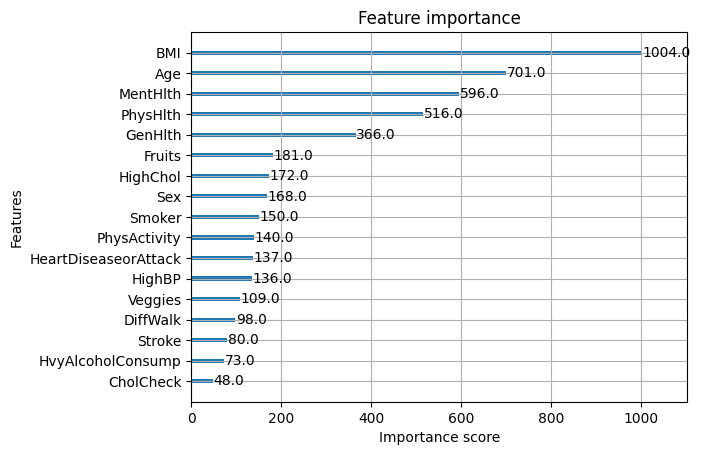

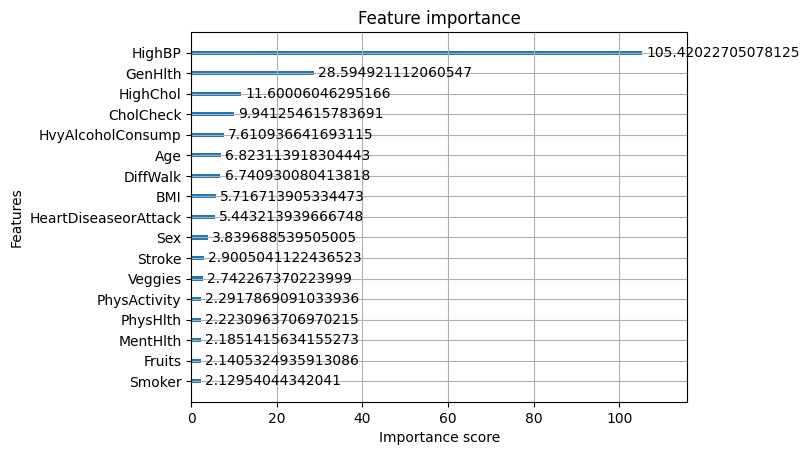

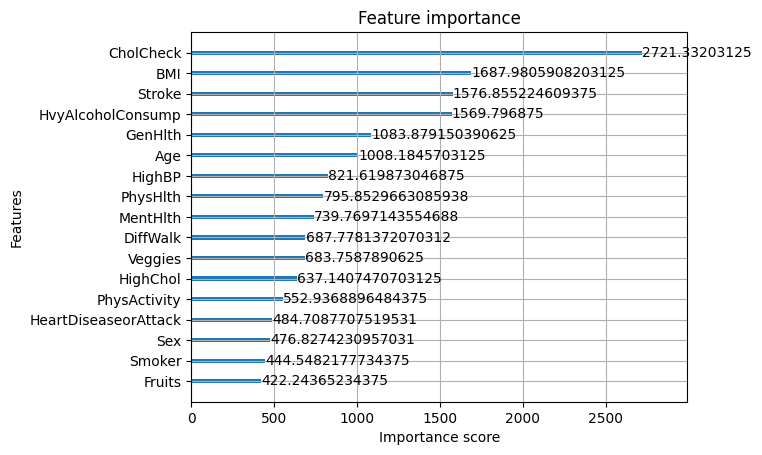

In [12]:
from xgboost import plot_importance

clf = pipeline.named_steps['classifier']
importances = clf.feature_importances_

plot_weight = plot_importance(clf, importance_type='weight')
plot_gain = plot_importance(clf, importance_type='gain')
plot_cover = plot_importance(clf, importance_type='cover')

2. ¿Los resultados obtenidos con los diferentes métodos son compatibles?, comente sus resultados y a que se debe la igualdad o desigualdad que ve en los resultados.

> **Respuesta:** En el caso de `weight`, las $3$ características con más importancia son `BMI` ($1004$), `Age` ($701$) y `MentHlth` ($596$). Para `gain`, son `HighBP` ($105\text{,}42$), `GenHlth` ($28\text{,}59$) y `HighChol` ($11\text{,}6$). Para `cover`, son `CholCheck` ($2721\text{,}33$), `BMI` ($1687\text{,}98$) y `Stroke` ($1576\text{,}85$). 
>
> La desigualdad (o incompatibilidad) que se ve en los resultados se debe a que estos $3$ métodos miden la importancia de manera distinta: `weight`, por un lado, mide qué tanto participó la variable en divisiones de nodos, `gain` mide la contribución promedio de una característica a la predicción del modelo, respondiendo a qué tanto se reduce la pérdida cuando se usa la variable para hacer un corte, y `cover` tiene que ver con cuántas observaciones son afectadas por el corte de una variable.
>
> La más usada para empezar es `gain`, dado que mide el impacto directo de una variable sobre las predicciones.

3. Finalmente, ¿las importancias obtenidas son suficientes para obtener la interpretabilidad de un modelo que utiliza árboles? ¿Qué debilidad presenta este método?

> **Respuesta:** No, no son suficientes para interpretar un modelo que utiliza árboles, porque tiene varias debilidades. Ejemplos de esto son:
> - Si hay dos variables correlacionadas y aportan intuitivamente a la predicción, el modelo puede elegir sólo una de las $2$ de manera arbitraria, dejando a la otra sin ninguna importancia.
> - Los modelos de árboles amplifican el sesgo estructural, pues prefieren las características que ofrecen más puntos de corte.

## 4. Métodos Agnósticos Globales (10 puntos)

<p align="center">
  <img src="https://media.tenor.com/JcRHtjVuXN8AAAAC/dr-simi-farmacias-similares.gif" width="400">
</p>

Tareas:
1. Para mitigar los problemas encontrados en la sección anterior, Dr. Simi le pide implementar un **método de permutación** que le permita observar la importancia de las features. `Nota:`Tenga cuidado con el orden de las columnas de este método. `Hint:` Puede obtener los features del clasificador con su respectivo orden mediante el método `.get_booster().feature_names` (2 puntos)
2. Para que su modelo sea consistente, repita el proceso **30 veces** y verifique la desviación estándar de sus resultados (¿Qué señala esta?). (2 puntos)
3. Visualice los resultados de este método en un gráfico. (2 puntos)
4. Además, responda las siguientes preguntas:
  - ¿Cómo mide la importancia de las features su propuesta? (1 punto)
  - ¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido? (1 punto)
  - ¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior? (1 punto)
  - Nombre y explique 3 ventajas y 3 desventajas del método implementado. (1 punto)

1. Para mitigar los problemas encontrados en la sección anterior, Dr. Simi le pide implementar un **método de permutación** que le permita observar la importancia de las features. `Nota:` Tenga cuidado con el orden de las columnas de este método. `Hint:` Puede obtener los features del clasificador con su respectivo orden mediante el método `.get_booster().feature_names`.

In [13]:
from sklearn.inspection import permutation_importance

ordered_features = clf.get_booster().feature_names
X_test_reordered = X_test[ordered_features]

result = permutation_importance(
  clf, 
  X_test_reordered, 
  y_test, 
  n_repeats=30, 
  random_state=RANDOM_STATE
)

summary = pd.DataFrame({
  'Feature': ordered_features,
  'Importance Mean': result.importances_mean,
  'Importance Std': result.importances_std,
  'Prop Std/Mean': result.importances_std / abs(result.importances_mean)
}).sort_values(by='Importance Mean', ascending=False)

summary

C:\Users\max02\AppData\Local\Temp\ipykernel_36180\4215328719.py:18: RuntimeWarning:

invalid value encountered in divide



,Feature,Importance Mean,Importance Std,Prop Std/Mean
16,HighBP,0.008401,0.000674,0.080235
4,PhysHlth,0.004397,0.000576,0.130924
6,HighChol,0.002952,0.000450,0.152385
7,CholCheck,0.002036,0.000450,0.220861
10,PhysActivity,0.001703,0.000369,0.216814
5,Sex,0.001075,0.000571,0.531194
15,Stroke,0.000866,0.000227,0.262030
8,Smoker,0.000820,0.000462,0.563189
13,HvyAlcoholConsump,0.000450,0.000183,0.406573
3,MentHlth,0.000218,0.000605,2.774969


2. Para que su modelo sea consistente, repita el proceso **30 veces** y verifique la desviación estándar de sus resultados (¿Qué señala esta?)

> **Respuesta:** En la mayoría de las características, la desviación estándar del resultado es menor que el $1\, \%$ de la media, lo que indica que los resultados son bastante estables, pues se habla de un error de $c \cdot \mu$, con $c < 1\, \%$. Sin embargo, hay características como `Veggies` que alcanza el valor máximo del error: $5\text{,}01\, \%$. Para esta variable, `HeartDiseaseorAttack` ($3\text{,}36\, \%$) y `MentHlth` ($2\text{,}77\, \%$) hay mayor incertidumbre, pero sigue siendo controlada.

3. Visualice los resultados de este método en un gráfico.

In [14]:
perm_sorted_idx = result.importances_mean.argsort()

fig = go.Figure()

for i in perm_sorted_idx:
  fig.add_trace(go.Box(
    x=result.importances[i, :],
    y=[ordered_features[i]],
    name=ordered_features[i],        
    orientation='h',
    boxpoints='all',
    jitter=0.3
  ))

fig.update_layout(
  title='Importancia de las <i>features</i> por incremento del error', 
  xaxis_title='Incremento del error (importancia)', 
  yaxis_title='Características', 
  showlegend=False,
  width=800,
  height=600
)

fig.show()

4. Además, responda las siguientes preguntas:
  - ¿Cómo mide la importancia de las features su propuesta?
> **Respuesta:** Lo que hace esta propuesta para medir la importancia de las características es, por cada una, permutar todos los valores que toman las observaciones en la columna asociada a dicha variable y evaluar la evolución del funcional de costo. Esto permite medir cuánto incrementa o disminuye el error al realizar este procedimiento, sin alterar la distribución ni los estadísticos de la variable.
  - ¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido?
> **Respuesta:** Las $5$ _features_ que tienen un mayor impacto, según esta técnica, son `HighBP` (si tiene la presión alterial alta o no), `PhysHlth` (índice de salud física), `HighChol` (si tiene colesterol alto o no), `CholCheck` (si se hizo una revisión de colesterol o no) y `PhysActivity` (si tiene actividad física o no). Todas tienen sentido con lo que se quiere predecir, que es si un paciente tiene diabetes o no, dado que son criterios fundamentales que tienen relación con esta condición médica.
  - ¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior?
> **Respuesta:** Las conclusiones cambian porque en el ítem anterior, tanto los métodos `weight` como `cover` mostraban a `BMI` (índice de masa corporal) como una variable importante, y ahora ya no está. El que más variables capturó en la intersección con este método fue `gain`, que también reportó `HighBP` y `HighChol` en las $3$ variables más importantes.
  - Nombre y explique 3 ventajas y 3 desventajas del método implementado.
> **Respuesta:** $3$ ventajas de este método son:
> 1. **Fácil interpretación**: el resultado para cada _feature_ es un número que responde a una pregunta intuitiva: ¿cuánto empeora el modelo si la característica se permuta completamente? 
> 2. **Alta compresión de interpretabilidad global**: da una idea de la importancia de las características para todo el conjunto de datos, no sólo para una predicción individual, y las comprime en un sólo número para cada una, lo que permite generar el _ranking_ graficado anteriormente.
> 3. **No se necesita reentrenar el modelo**: no necesita borrar una característica y entrenar el modelo desde cero, lo que lo hace computacionalmente eficiente.
>
> Y $3$ desventajas son:
> 1. **Enlazado al error del modelo**: la importancia de una característica depende netamente de la métrica de error (funcional de costo) que se elige.
> 2. **Se necesita acceso a la _gold label_**: se necesita el valor real de la observación. Si no se posee la respuesta correcta, como en nuevos datos para predicción, no se puede ocupar.
> 3. **Si hay _features_ correlacionadas puede generar sesgo por entradas poco realistas**: el hecho de permutar puede generar combinaciones poco realistas, por ejemplo, que en Santiago haya una temperatura de $-20°\, \text{C}$.

## 5. Métodos Agnósticos Locales (20 puntos)

<p align="center">
  <img src="https://i.makeagif.com/media/10-24-2024/oMCrLI.gif" width="400">
</p>

### 5.1 Calculando Shap Values (4 puntos)

Tareas:
1. Alegre por saber cómo funciona el modelo de predicción a nivel general, Dr. Simi le pide ahora interpretar las predicciones de su modelo a nivel de paciente (es decir, desde un punto de vista **local**). Para esto, el ilustre farmacéutico le pide calcular los *shap values* de su modelo. (2 puntos)
2. ¿Qué representa cada número en su resultado? (1 punto)
3. ¿Es posible atribuir un significado a la positividad/negatividad de cada valor? (1 punto)

In [15]:
import warnings
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")

1. Alegre por saber cómo funciona el modelo de predicción a nivel general, Dr. Simi le pide ahora interpretar las predicciones de su modelo a nivel de paciente (es decir, desde un punto de vista **local**). Para esto, el ilustre farmacéutico le pide calcular los *shap values* de su modelo. 

In [16]:
import shap

explainer = shap.TreeExplainer(clf)
X_test_transformed = pipeline.named_steps['preprocessor'].transform(X_test)
shap_values = explainer.shap_values(X_test_transformed)

pd.DataFrame(shap_values, columns=X_test_transformed.columns).head()

,Age,GenHlth,BMI,MentHlth,PhysHlth,Sex,HighChol,CholCheck,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,DiffWalk,Stroke,HighBP
0,0.192400,1.145876,-0.675378,0.061001,0.184467,-0.124083,0.289678,0.026960,-0.013418,-0.023322,0.020658,0.022613,-0.023810,0.035031,-0.049467,-0.023906,-0.623051
1,0.575245,0.216856,0.548359,0.062641,-0.002888,-0.127224,-0.289867,0.021952,0.016209,-0.061521,0.051956,-0.020111,-0.041483,0.021411,0.121022,-0.011934,-0.613815
2,-0.210392,-0.711990,-0.278570,0.027195,-0.108647,0.036675,0.268842,0.018107,0.065777,-0.035851,-0.011476,-0.011524,-0.041105,0.028512,-0.087864,-0.012917,0.514605
3,-0.195358,0.383723,0.102290,0.078572,-0.143621,0.001972,0.320699,0.024882,0.043282,-0.047738,0.030311,0.017669,0.134026,0.023337,-0.040602,-0.006328,-0.590802
4,-0.709571,0.634117,1.192900,0.221236,0.240964,0.046535,-0.469641,0.026451,0.037629,-0.067939,0.054666,-0.069352,-0.002109,0.016333,0.192611,-0.035381,0.526952


2. ¿Qué representa cada número en su resultado? 

> **Respuesta:** Cada número $M_{i j}$ de la matriz $M$ calculada (cuyo muestreo se realizó con `head()`) indica el _logit_ ($\log p/(1-p)$) asociado a la $j$-ésima variable del modelo, para la $i$-ésima observación, donde $p$ es la probabilidad de clase asignada. En un modelo básico, si $p\ge 0\text{,}5$, la clase predicha es positiva, y si no, es negativa. Sin embargo, este umbral $0\text{,}5$ se puede cambiar.

3. ¿Es posible atribuir un significado a la positividad/negatividad de cada valor?
> **Respuesta:** Sí. Si el número $M_{i j}$ es positivo, quiere decir que para la observación $i$, la variable $j$ "empuja" la predicción hacia la clase positiva, dado que $p/(1-p) > 1 \implies p > 0\text{,}5$. Si es negativo, entonces la variable $j$ "empuja" la predicción de la misma observación, pero hacia la clase negativa.

### 5.2 Aporte local (4 puntos)

1. Usando los *shap values* calculados, grafique el **aporte local** de las diferentes variables para las instancias **1**, **9** y **150** (1 punto).

2. Interprete sus resultados y responda:

  - ¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes? (1 punto)

  - ¿Existe algún patrón común entre las instancias analizadas? (1 punto)

  - ¿Es posible generalizar estas conclusiones a todo el dataset? (1 punto)

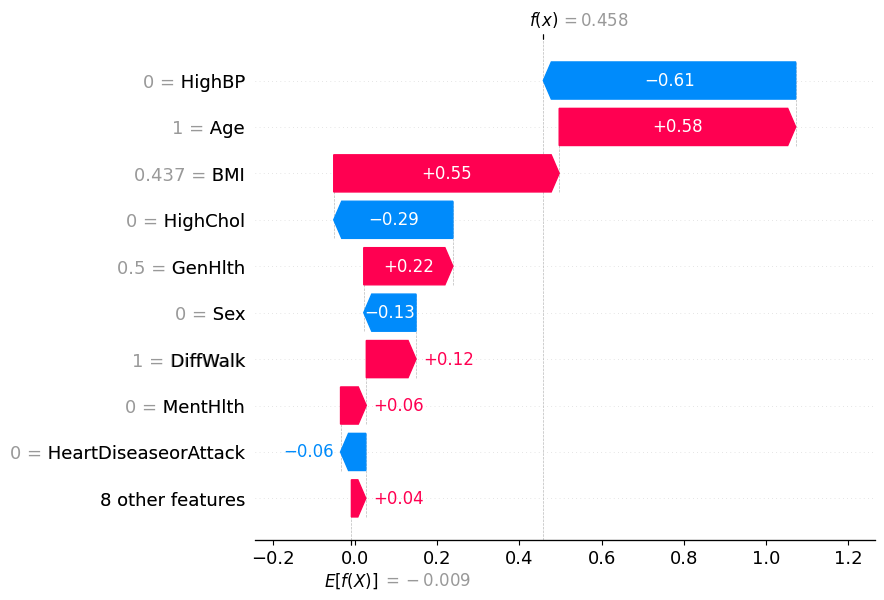

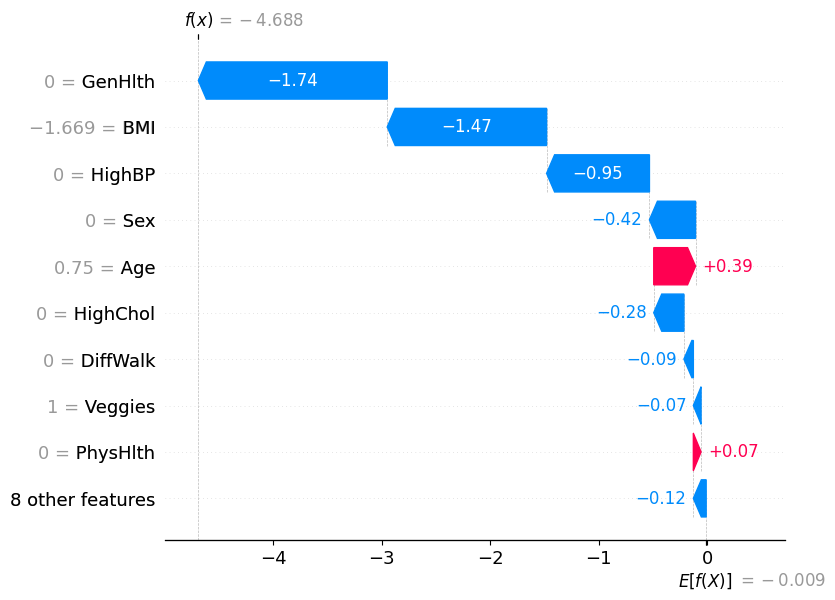

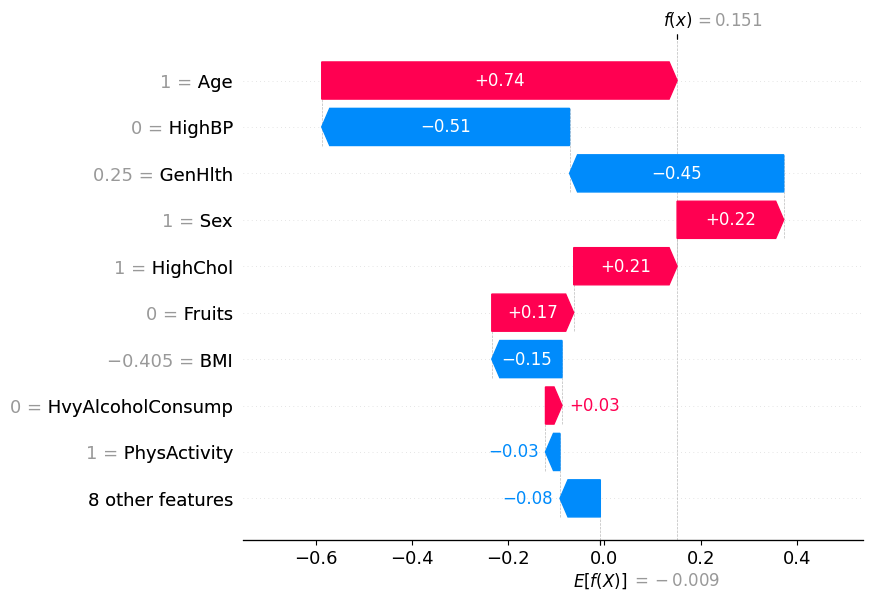

In [17]:
indices = [1, 9, 150]

for idx in indices:
  explanation = shap.Explanation(
    values=shap_values[idx, :],
    base_values=explainer.expected_value,
    data=X_test_transformed.iloc[idx, :],
    feature_names=X_test_transformed.columns.tolist()
  )

  shap.plots.waterfall(explanation)

2. Interprete sus resultados y responda:

  - ¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes?
  > **Respuesta:** Para la observación $1$, las $3$ variables que más afectan son: `HighBP` (_shap value_: $-0\text{,}61$; indica si el paciente en el índice $1$ tiene presión alta o no), `Age` (_shap value_: $+0\text{,}58$; indica la edad del paciente en el índice $1$) y `BMI` (_shap value_: $+0\text{,}55$; indica el índice de masa corporal del paciente en el índice $1$).
  >
  > Para la observación $9$, las $3$ variables que más afectan son `GenHlth` (_shap value_: $-1\text{,}74$; indica el índice de salud general para este paciente), `BMI` (_shap value_: $-1\text{,}47$) y `HighBP` (_shap value_: $-0\text{,}95$). Todos afectan de manera negativa. La primera que afecta de manera positiva está quinta en el orden decreciente por valor absoluto, y corresponde a `Age` (_shap value_: $+0\text{,}39$).
  >
  > Finalmente, para la observación $150$, las $3$ variables que más afectan son `Age` (_shap value_: $+0\text{,}74$), `HighBP` (_shap value_: $-0\text{,}51$) y `GenHlth` (_shap value_: $-0\text{,}45$).

  - ¿Existe algún patrón común entre las instancias analizadas?
  > **Respuesta:** Sí, existe un patrón, y es que las $3$ instancias analizadas consideran importante dentro de su top $3$ (por valor absoluto) a la variable `HighBP`. También, se repiten entre las más importantes: `Age`, `GenHlth` y `BMI`. Estas $4$ variables, y principalmente `HighBP`, son muy examinadas por un médico a la hora de analizar una sospecha de diabetes, así que tiene sentido en el contexto del problema.

  - ¿Es posible generalizar estas conclusiones a todo el dataset?
  > **Respuesta:** No, porque estos son $3$ pacientes en particular, y la inspección se hizo de manera local para cada uno de ellos (por eso se habla de un _modelo agnóstico local_). Perfectamente, otro paciente podría arrojar otro orden de importancia.

### 5.3 Aporte global (4 puntos)

Genere ahora una visualización donde se grafique el aporte de cada feature a nivel **global** e interprete sus resultados. ¿Qué diferencias existen con las conclusiones generadas a nivel de instancia?

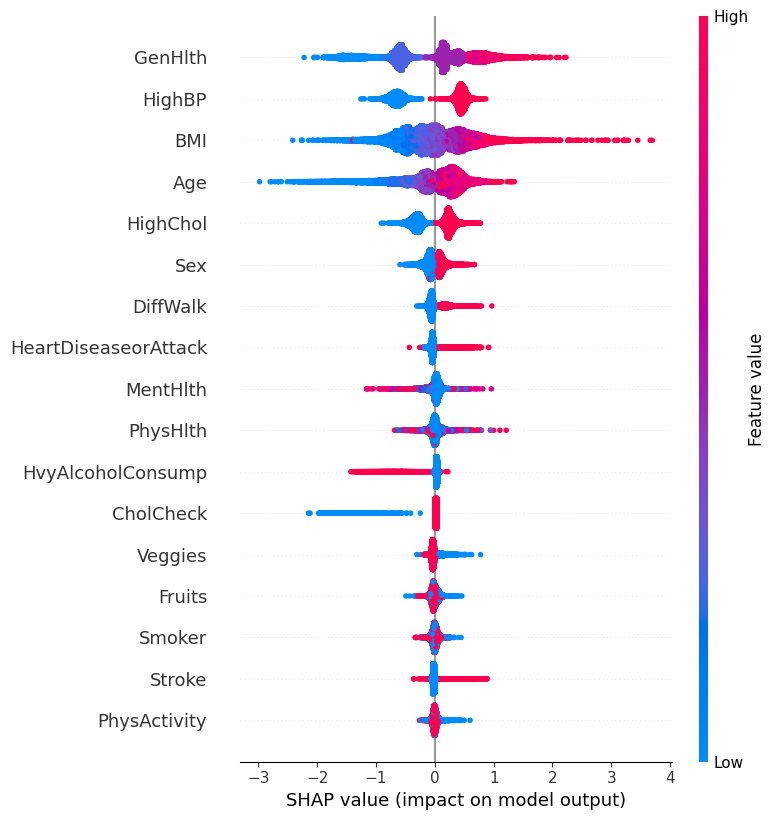

In [18]:
shap.summary_plot(
  shap_values,
  X_test_transformed,
  feature_names=X_test_transformed.columns.tolist()
)

- Interprete sus resultados.
> **Respuesta:** En resumen, `GenHlth` (índice de salud general), `HighBP` (si posee alta presión corporal o no), `BMI` (índice de masa corporal) y `Age` (edad) son las variables más relevantes a nivel global. Un índice de salud alto está asociado a un _shap value_ alto, es decir, este índice probablemente representa peor salud mientras más grande es. Por otro lado, el tener una presión corporal alta también aumenta el riesgo de padecer diabetes según el modelo. Lo mismo ocurre con un índice de masa corporal y una edad mayor.

- ¿Qué diferencias existen con las conclusiones generadas a nivel de instancia?
> **Respuesta:** Con respecto a las conclusiones a nivel de instancia, previamente se había establecido que en las instancias $1$, $9$ y $150$, las variables que se compartían entre las más importantes eran `HighBP`, `Age`, `GenHlth` y `BMI`. Estas variables se vuelven a repetir, por ende, no existen diferencias significativas en la interpretabilidad, y esta interpretación global permite confirmar las sospechas iniciales, dado que todos esos pacientes no tenían alta presión corporal (por ende, sus _shap values_ asociados empujaban la predicción hacia la clase negativa), tenían una edad alta dentro del _dataset_ después del escalado MinMax (por ende, sus _shap values_ asociados empujaban la predicción hacia la clase positiva), y poseían un índice `GenHlth` y `BMI` bajo después del escalado, salvo el paciente $1$, pero los _shap values_ se movieron en la dirección esperada.
>
> Esto último es relevante, porque en la interpretación global se puede observar, por ejemplo, que en `Age` hay pacientes con alta edad que aún así empujan la predicción por esta variable hacia la clase negativa. Esto puede deberse a condiciones atípicas que estaría bueno confirmar con un experto en salud.

### 5.4 Scatter plot (4 puntos)


Grafique ahora un *scatterplot* entre los *shap values* y las primeras 5 features con mayor impacto global (un gráfico por cada feature), coloreando cada punto por la probabilidad de tener diabetes. ¿Qué puede concluir de sus resultados?

In [19]:
model_probabilities = clf.predict_proba(X_test_transformed)[:, 1]

shap_df = pd.DataFrame(shap_values, columns=X_test_transformed.columns)
top_features = shap_df.abs().mean().sort_values(ascending=False).index[:5]

for feature in top_features:
  fig = go.Figure()

  fig.add_trace(go.Scatter(
    x=X_test_transformed[feature],
    y=shap_df[feature],
    mode='markers',
    marker=dict(
      color=model_probabilities,
      colorscale='RdBu',  
      showscale=True,
      colorbar=dict(
        title='Probabilidad de padecer diabetes'
      )
    )
  ))

  fig.update_layout(
    title=f'Gráfico de Dependencia SHAP para "{feature}"',
    xaxis_title=f'Valor de la característica "{feature}"',
    yaxis_title=f'Valor SHAP (Impacto en la predicción)'
  )

  fig.show()

- ¿Qué puede concluir de sus resultados?
> **Respuesta:** En el gráfico para `GenHlth` se puede ver que a medida que este índice aumenta, la probabilidad de padecer diabetes también aumenta, dada la densidad de puntos azules que se concentran en torno al $1$ (valor máximo). Esto también pasa para `BMI` y `Age`, pero en otra escala. Para `HighBP` no hay una relación clara: los puntos azules y rojos se concentran tanto en $0$ (no tiene presión alta) como en $1$ (sí tiene presión alta). Sin embargo, en el valor $1$ se ve que hay más puntos tendiendo a color azul, lo que indica que el poseer esta condición sí puede aumentar la probabilidad. Esto mismo ocurre con `HighChol`.

### 5.5 Partial Dependence Plot (4 puntos)

Finalmente, se le pide generar un gráfico del tipo Partial Dependence Plot para las mismas 5 variables con mayor impacto global usando una submuestra de 1000 observaciones. ¿Qué relación existe entre la salida promedio del modelo y cada feature analizada? ¿Son estas conclusiones generalizables para todo el conjunto de datos?

Graficando para: GenHlth


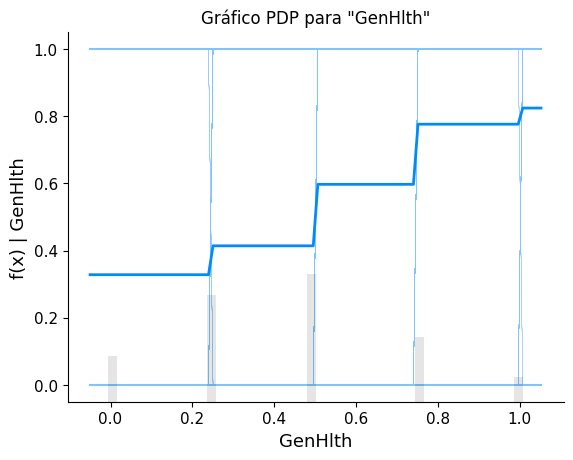

Graficando para: HighBP


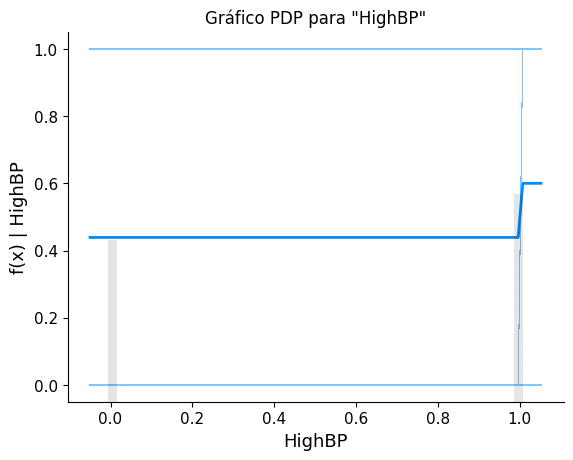

Graficando para: BMI


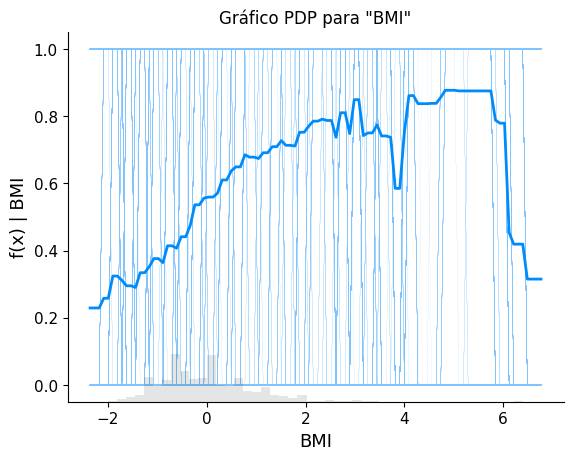

Graficando para: Age


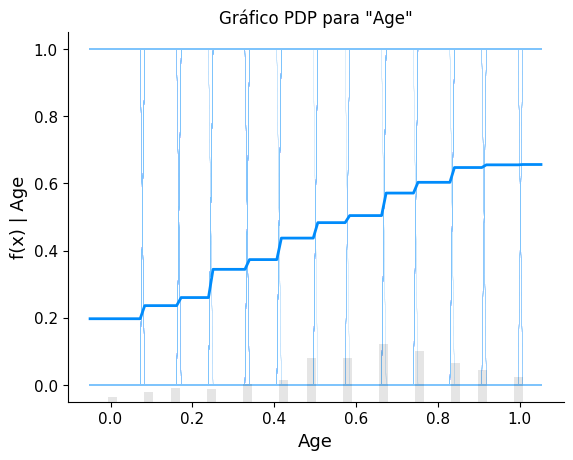

Graficando para: HighChol


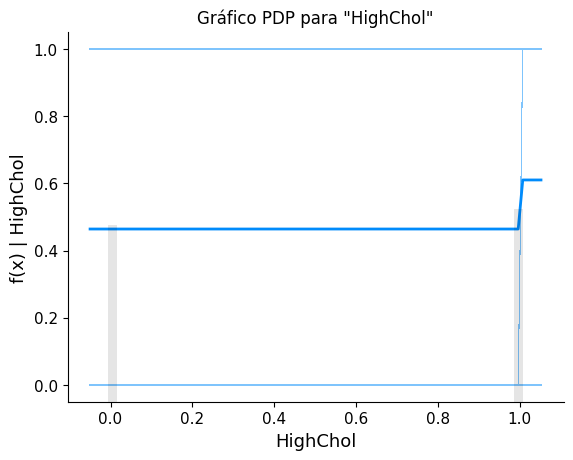

In [20]:
from matplotlib import pyplot as plt

subsample_idx = np.random.choice(
  X_test_transformed.index, 
  size=1000, 
  replace=False
)

shap_df = pd.DataFrame(
  shap_values,
  columns=X_test_transformed.columns, 
  index=X_test_transformed.index
)

subsample_data = X_test_transformed.loc[subsample_idx, :]
subsample_shap_values = shap_df.loc[subsample_idx, :]

for feature in top_features:
  print(f"Graficando para: {feature}")
  
  shap.partial_dependence_plot(
    feature,
    clf.predict,
    subsample_data, 
    ice=True, 
    show=False 
  )
  
  plt.title(f'Gráfico PDP para "{feature}"')
  plt.show()

- ¿Qué relación existe entre la salida promedio del modelo y cada feature analizada? 
> **Respuesta:** Para `HighChol` y `HighBP` (binarias), se ve que cuando toma el valor $0$, la salida promedio del modelo es aproximadamente $0\text{,}4$, y cuando toma el valor $1$ (tiene colesterol alto o presion alta), esta sube a $0\text{,}6$, indicando que la probabilidad de padecer diabetes aumenta. Para `Age` y `GenHlth` se ve que la salida promedio del modelo va aumentando de manera escalonada, a medida que la variable independiente (_feature_) aumenta en su escala. Para `GenHlth` empieza en $\sim 0\text{,}4$ y termina en $\sim 0\text{,}8$, mientras que para `Age` empieza en $\sim 0\text{,}2$ y termina en $\sim 0\text{,}6$. De nuevo, se muestra una tendencia que aumenta la probabilidad de padecer diabetes a medida que estas variables aumentan. Finalmente, `BMI` tiene un comportamiento por saltos: hay intervalos donde esta probabilidad crece (p. ej., $[-2, 2]$) e intervalos donde decrece (p. ej., $[5\text{,}5; 6\text{,}25]$).

- ¿Son estas conclusiones generalizables para todo el conjunto de datos?
> **Respuesta:** No completamente, pero sí es una muy buena aproximación. Esto es porque el análisis se realizó sobre una submuestra de tamaño $1.000$ y no sobre todo el _dataset_, entonces, la línea PDP es una estimación, y existe el riesgo de que la submuestra analizada no capture el comportamiento de subgrupos atípicos.

## 6. Sistema de Reglas! (10 punto)

<p align="center">
  <img src="https://media.baamboozle.com/uploads/images/125978/1638281150_1380186_gif-url.gif" width="400">
</p>

Después de todo el trabajo hecho, Dr. Simi le pide simplificar el funcionamiento de su modelo en un sistema de reglas que le permita explicar a sus clientes las predicciones que genera su modelo.
En particular, Dr. Simi le pide explicar la decisión tomada para las observaciones **1000**, **3001** y **5751**. Con las reglas propuestas señale a **cuánta población** es posible explicar con estas reglas e indique la **precisión** que poseen las reglas en la totalidad de los datos. ¿Tienen sentido sus reglas propuestas para las observaciones?. Fundamente sus respuesta señalando el impacto que tienen sus reglas sobre todo el conjunto de datos.

`Hint:` Como debe entregar las columnas que entran al clasificador entrenado de su pipeline, le será útil extraer el paso de preprocesamiento y generar dataframes preprocesados para el conjunto `train` y `test`.

In [21]:
from alibi.explainers import AnchorTabular

In [29]:
preprocessor = pipeline.named_steps['preprocessor']
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
X_train_processed_df = pd.DataFrame(
  X_train_processed,
  columns=feature_names,
  index=X_train.index
)
X_test_processed_df = pd.DataFrame(
  X_test_processed,
  columns=feature_names,
  index=X_test.index
)

final_classifier = pipeline.steps[-1][1]
predict_fn = final_classifier.predict

explainer = AnchorTabular(predict_fn, feature_names)

explainer.fit(X_train_processed_df.values)

indices = [1000, 3001, 5751]
for idx in indices:
  instance = X_test_processed_df.loc[idx].values
  explanation = explainer.explain(instance, threshold=0.95)
  
  print(f"\n Explicación para la instancia {idx}:")
  print(f"Reglas: {explanation.anchor}")
  print(f"Cobertura: {explanation.coverage}")
  print(f"Precisión: {explanation.precision}")
  print(f"Predicción explicada: {explanation.raw['prediction']}")


 Explicación para la instancia 1000:
Reglas: ['GenHlth <= 0.25', 'HighBP <= 0.00', 'BMI <= -0.69']
Cobertura: 0.1128
Precisión: 0.9774436090225563
Predicción explicada: [0]

 Explicación para la instancia 3001:
Reglas: ['BMI <= -0.69', 'HighBP <= 0.00', 'HighChol <= 0.00']
Cobertura: 0.1213
Precisión: 0.9502958579881656
Predicción explicada: [0]

 Explicación para la instancia 5751:
Reglas: ['GenHlth <= 0.25', 'HighBP <= 0.00', 'BMI <= -0.69']
Cobertura: 0.1099
Precisión: 0.9868852459016394
Predicción explicada: [0]


- En particular, Dr. Simi le pide explicar la decisión tomada para las observaciones **1000**, **3001** y **5751**.
> **Respuesta**: Para todos los ejemplos, el modelo predice la etiqueta $0$ (no tiene diabetes). La razón principal para esta predicción es, para la instancia $1.000$, que `GenHlth <= 0.25` (tiene un índice de salud general bueno), `HighBP <= 0.0` (en particular, como es binaria, sólo puede ser $0$, e indica que no tiene la presión corporal alta) y `BMI <= -0,69` (un índice de masa corporal bajo). Para la instancia $3.001$ se usa que `BMI <= -0,69`, `HighBP <= 0.0` (ya explicados) y que `HighChol <= 0.0` (como es binaria, sólo puede ser $0$, e indica que no tiene el colesterol alto). Finalmente, para la observación $5.751$ se usa que `GenHlth <= 0.25`, `HighBP <= 0.0` y `BMI <= -0,69`, todos ya explicados. Estos resultados son consistentes con el análisis que se ha hecho durante este trabajo.

- Con las reglas propuestas señale a **cuánta población** es posible explicar con estas reglas e indique la **precisión** que poseen las reglas en la totalidad de los datos.

> **Respuesta**: Con el ejemplo $1.000$ se posee una cobertura de $0\text{,}1128$ y una precisión de $0\text{,}97$. Esto quiere decir, respectivamente, que la regla es bastante general, dado que aplica para casi el $11\text{,}3\, \%$ del conjunto de datos, y es fiable, porque del total de personas que están en el vecindario de los datos que cumplen estas tres condiciones, el $97\text{,}7\, \%$ también reciben una predicción con etiqueta $0$ (no tiene diabetes). Para el ejemplo $3.001$ la cobertura es del $12\text{,}1\, \%$ y la precisión es del $95\, \%$, y para el $5.751$ la cobertura es del $11\, \%$ y la precisión es del $98\, \%$. Estos números tienen la misma interpretación dada al inicio para la observación $1.000$.

- ¿Tienen sentido sus reglas propuestas para las observaciones?
> **Respuesta:** Sí, las reglas propuestas tienen sentido, porque todas las observaciones fueron clasificadas como pacientes no diabéticos, y cumplen tener condiciones sanas: un buen índice de salud general, no tener la presión corporal ni el colesterol altos, y tener un IMC bajo, lo que se ha mantenido consistente en el estudio.

- Fundamente sus respuesta señalando el impacto que tienen sus reglas sobre todo el conjunto de datos.
> **Respuesta:** Las variables que se consideraron en las reglas son importantes en la predicción según los análisis realizados anteriormente tanto con _modelos agnósticos locales_ como _globales_.

# Retrospectiva... (10 puntos)

En base a los diferentes métodos que implementa y ha comentado en este laboratorio, comente qué métodos le permiten entregar mejores conclusiones para la tarea de clasificación de diabetes. Por otro lado, ¿qué métodos son más útiles para el problema del doctor Simi, métodos agnosticos locales o globales?

> **Respuesta:** Considerando que se exploraron métodos de explicabilidad más focalizados en el modelo _XGBoost_, como lo es _Feature Importance_ con los diversos métodos _weight_, _cover_ y _gain_, que buscaban cuantificar la importancia de las variables mediante diferentes algoritmos de metrización, lo cual arrojó que diversas _features_ cambiaban su importancia sobre la decisión del modelo. En este caso, se pudo ver que según cada método, la importancia de las variables se alteraba, en el caso de `weight`, las $3$ características con más importancia son `BMI` ($1004$), `Age` ($701$) y `MentHlth` ($596$). Para `gain`, son `HighBP` ($105\text{,}42$), `GenHlth` ($28\text{,}59$) y `HighChol` ($11\text{,}6$). Para `cover`, son `CholCheck` ($2721\text{,}33$), `BMI` ($1687\text{,}98$) y `Stroke` ($1576\text{,}85$). **El que permitió obtener mejores conclusiones para este caso fue `gain`, dado que está centrado en cómo varía el funcional de pérdida que se está optimizando.**
>
> Posteriormente, se probó con _modelos agnósticos_, inicialmente con _Permutation Feature Importance_ (_agnóstico global_), el cual mediante permutaciones de valores en las variables, evalúa la variación del error de modelo. **Los resultados de este modelo hay que analizarlos con pinzas**, dado que es sensible a las correlaciones entre variables, por lo tanto, podría ser útil en el caso de pocos datos, con supuestos de no multicolinealidad, el cual no es el caso, dado que hay variables clínicas que están intrínsecamente relacionadas (p. ej., todas las que tratan el colesterol).
>
> En el caso de los _modelos agnósticos locales_, se utilizó _SHAP values_ para entender de mejor forma el impacto de las variables en casos individuales. Esto es particularmente útil si, por ejemplo, el Dr. Simi buscara explicar a pacientes con diferentes registros, qué variables influyen más en su diagnóstico, lo que se podría dar en el escenario de una consulta médica. Los resultados entregados por _SHAP values_ aportaron bastante al análisis de importancia, dado que el análisis _agnóstico global_ que se hizo posteriormente promediando los valores _SHAP_ de cada observación generó un resultado consistente con el comportamiento local, **permitiendo extraer hallazgos de valor** (como por ejemplo, las $5$ variables de mayor importancia). Aquí, el análisis de los PDP permitió confirmar cómo se mueve en promedio la probabilidad de pertenecer a la clase positiva cuando varía una característica y las demás se mantienen constantes.
>
> Por último, el _modelo agnóstico local_ por anclas (_anchors_) permite saber cuáles son las reglas que deciden una predicción, cubriendo una vecindad de ejemplos que cumplen las mismas reglas, con una cierta precisión. **Esta técnica fue útil para concluir sobre un nivel de confianza y cobertura local**.
>
> Así, dependiendo del objetivo del doctor Simi, se utilizaría un _modelo agnóstico_ diferente. Si quiere realizar inferencias globales, como por ejemplo, para ver factores de riesgo en una población, le recomendaríamos _Permutation Feature Importance_ teniendo cuidado con las correlaciones en la etapa de _Feature Engineering_. Si quiere explicabilidad a nivel persona a persona, como en el caso de una consulta, sería de mayor valor _SHAP values_, ya que este es especializado en análisis caso a caso, o también _anchors_ para poder explicar por rangos ciertas predicciones.